In [12]:
# Set up the file path
import os
os.chdir('..')

In [13]:
# Import packages
import numpy as np
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [14]:
# Create mass-action reactions
# r1 = MassAction([], ['Z_1'], ['u_1'], [1.])
# r2 = MassAction(['X_2'], ['X_2', 'Z_2'], [None], [2])
# r3 = MassAction(['Z_1', 'Z_2'], [], [None], [100])
# r4 = MassAction(['Z_1'], ['Z_1', 'X_1'], [None], [3])
# r5 = MassAction(['X_1'], ['X_1', 'X_2'], [None], [2])
# r6 = MassAction(['X_1'], [], [None], [2])
# r7 = MassAction(['X_2'], [], [None], [2])

# Zhou's secret hill-function CRN 
r1 = MassAction([], ['X_1'], ['u_1'], [1.0])
r2 = MassAction(['X_3'], [], [None], [1.0])
r3 = MassAction(['X_1', 'X_3'], ['X_1', 'X_1'], [None], [28.797096252441406])
r4 = MassAction(['X_1'], ['X_3'], [None], [28.564558029174805])
r5 = MassAction(['X_1', 'X_2'], ['X_2'], [None], [21.710105895996094])
r6 = MassAction(['X_2'], ['X_1', 'X_2'], [None], [25.092517852783203])
r7 = MassAction(['X_2', 'X_3'], ['X_2', 'X_2'], [None], [22.639039993286133])

In [15]:
# Create and compile the IOCRN
iocrn = IOCRN(reactions=[r1, r2, r3, r4, r5, r6, r7], output_labels=['X_3'], solver='CVODE', atol=1e-6, rtol=1e-6)
iocrn.compile()
num_inputs = iocrn.num_inputs
print(iocrn)
print("Number of inputs:", num_inputs)

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(28.797096252441406)]
X_1 ----> X_3;  [MAK(28.564558029174805)]
X_1 + X_2 ----> X_2;  [MAK(21.710105895996094)]
X_2 ----> X_1 + X_2;  [MAK(25.092517852783203)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(22.639039993286133)]
Number of inputs: 1


In [16]:
# Construct initial conditions
ic = IC(iocrn.species_labels, values= [
    [0., 0., 0.],
])
x0_list = ic.get_ic(iocrn)
print(x0_list)

[array([0., 0., 0.])]


In [17]:
# Construct inputs
nums = [0.5, 1.0, 1.5]
u_list = [np.array(u) for u in product(nums, repeat=num_inputs)] # list of input combinations, each input is a numpy array of shape (p,)
print(u_list)

[array([0.5]), array([1.]), array([1.5])]


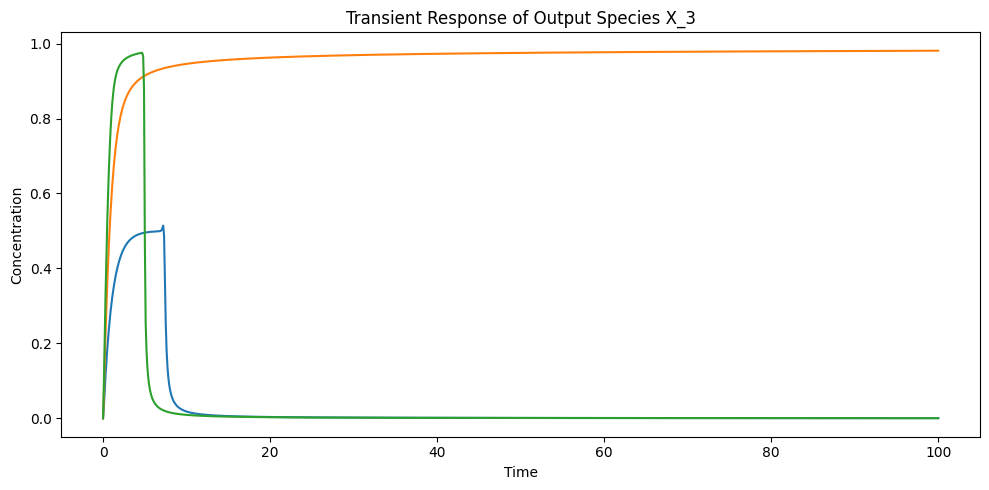

In [18]:
# Simulate Dynamics
time_horizon = np.linspace(0, 100.0, 1000, dtype=np.float32)
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)


# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 1)

In [19]:
# # Construct the weights for the performance metric
# N_t = 1000
# w = np.zeros(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:] + 1
# w[:(len(w)//5)] = w[:(len(w)//5)]*0
# w = w[np.newaxis, :]

# # Compute Reward
# def compute_reward(state):
#    r_list = [np.array([u[0]]) for u in u_list]
#    print(r_list)
#    x0_list = ic.get_ic(state)
#    out = dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)
#    return out

# print(compute_reward(iocrn))

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(28.797096252441406)]
X_1 ----> X_3;  [MAK(28.564558029174805)]
X_1 + X_2 ----> X_2;  [MAK(21.710105895996094)]
X_2 ----> X_1 + X_2;  [MAK(25.092517852783203)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(22.639039993286133)]


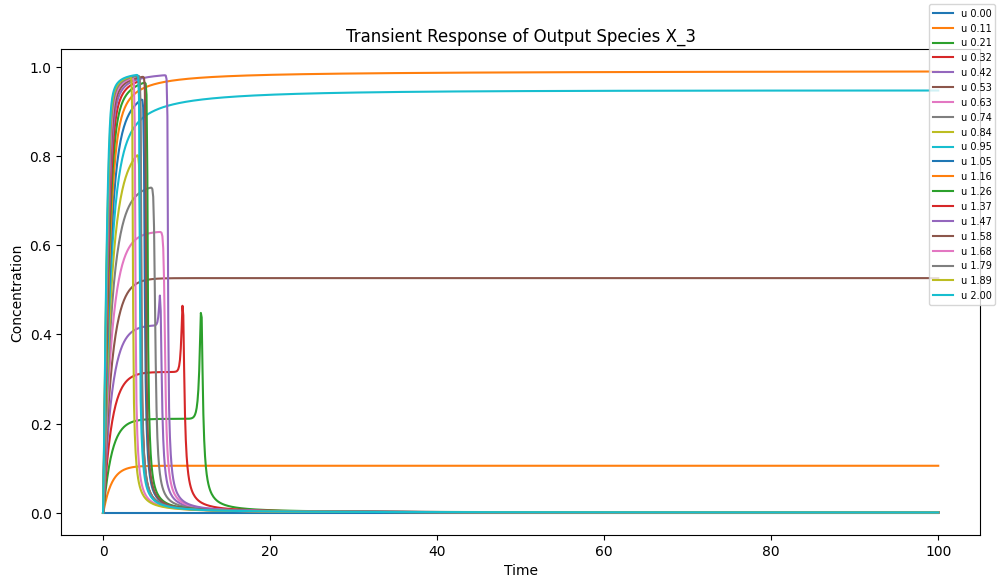

In [20]:
iocrn.reactions[0].set_parameters([1.])
iocrn.reset()
print(iocrn)
nums = np.linspace(0.0, 2.0, 20)
u_list = [np.array(u) for u in product(nums, repeat=1)]
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)
fig, ax = iocrn.plot_transient_response(alpha = 1)
# use only 2 decimal places in legend
fig.legend([f"u {u[0]:.2f}" for u in u_list], fontsize=7)
# size 
fig.set_size_inches(10, 6)


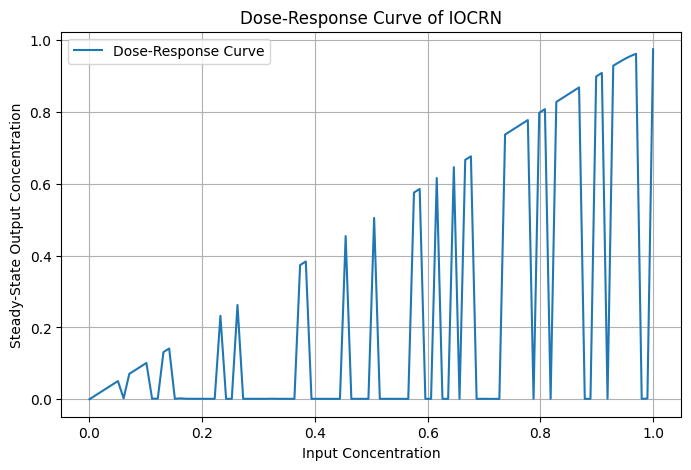

In [21]:
# plot dose-response curve

import matplotlib.pyplot as plt
inputs = np.linspace(0, 1, 100)
steady_state_outputs = []

iocrn.reactions[0].set_parameters([1.])

for inp in inputs:
    iocrn.reset() 
    u = [np.array([inp])]
    t, x, y, task_info = iocrn.transient_response(u, x0_list, np.linspace(0, 50, 10000))
    steady_state_outputs.append(y[0][-1, -1]) 
    iocrn.reset()  
    
plt.figure(figsize=(8, 5))
plt.plot(inputs, steady_state_outputs, label='Dose-Response Curve')
plt.xlabel('Input Concentration')
plt.ylabel('Steady-State Output Concentration')
plt.title('Dose-Response Curve of IOCRN')
plt.legend()
plt.grid()
plt.show()
# save figure
# plt.savefig('dose_response_curve.png', dpi=300)

In [22]:
print(iocrn)

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(28.797096252441406)]
X_1 ----> X_3;  [MAK(28.564558029174805)]
X_1 + X_2 ----> X_2;  [MAK(21.710105895996094)]
X_2 ----> X_1 + X_2;  [MAK(25.092517852783203)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(22.639039993286133)]
